# Fuzzy C-Means Deep Analysis
Focus: membership topology, hyperparameter sweep, fuzzy-only metrics, VRI comparison across all methods.

## 1. Setup & Data Loading

In [ ]:
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import pairwise_distances_argmin_min
from skimage.morphology import remove_small_objects
from skimage.measure import label as sk_label, regionprops
from scipy.ndimage import distance_transform_edt, binary_erosion
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

import skfuzzy as fuzz

np.random.seed(123)

In [2]:
shapefile_path = 'data/vineyard_shape.shp'
vineyard_vector = gpd.read_file(shapefile_path)

def load_and_crop_raster(raster_path, shapes):
    with rasterio.open(raster_path) as src:
        out_image, _ = mask(src, shapes.geometry, crop=True)
        return out_image[0]

nir_raw  = load_and_crop_raster('data/CROPPED_ORTHOMOSAIC_240618_NIR.tif', vineyard_vector)
re_raw   = load_and_crop_raster('data/CROPPED_ORTHOMOSAIC_240618_RE.tif',  vineyard_vector)
r_raw    = load_and_crop_raster('data/CROPPED_ORTHOMOSAIC_240618_R.tif',   vineyard_vector)
g_raw    = load_and_crop_raster('data/CROPPED_ORTHOMOSAIC_240618_G.tif',   vineyard_vector)
ndvi_raw = load_and_crop_raster('data/CROPPED_ORTHOMOSAIC_240618_NDVI.tif',vineyard_vector)

min_h = min(nir_raw.shape[0], re_raw.shape[0], r_raw.shape[0], g_raw.shape[0], ndvi_raw.shape[0])
min_w = min(nir_raw.shape[1], re_raw.shape[1], r_raw.shape[1], g_raw.shape[1], ndvi_raw.shape[1])

nir  = nir_raw[:min_h, :min_w].astype(float)
re   = re_raw[:min_h, :min_w].astype(float)
r    = r_raw[:min_h, :min_w].astype(float)
g    = g_raw[:min_h, :min_w].astype(float)
ndvi = ndvi_raw[:min_h, :min_w].astype(float)

ndre = (nir - re) / (nir + re)
ndre = np.nan_to_num(ndre, nan=0.0, posinf=0.0, neginf=0.0)
valid_mask_2d = ndre > 0.1

multi_features = np.column_stack((
    ndre[valid_mask_2d], ndvi[valid_mask_2d],
    nir[valid_mask_2d],  r[valid_mask_2d], g[valid_mask_2d]
))
unscaled_data = multi_features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(multi_features)

OPTIMAL_K = 3
SAMPLE_SIZE = min(30000, scaled_data.shape[0])
idx_sample = np.random.choice(scaled_data.shape[0], size=SAMPLE_SIZE, replace=False)
X_sample = scaled_data[idx_sample]

print(f'Valid pixels: {np.sum(valid_mask_2d):,} | Feature array: {scaled_data.shape}')

Valid pixels: 26,244,582 | Feature array: (26244582, 5)


In [ ]:
def sort_labels_by_ndre(labels, features_unscaled):
    uniq = np.unique(labels)
    means = [(c, np.mean(features_unscaled[labels == c, 0])) for c in uniq]
    means.sort(key=lambda x: x[1])
    mapping = {old: new + 1 for new, (old, _) in enumerate(means)}
    return np.array([mapping[l] for l in labels])

def apply_casp(raw_map, valid_mask, n_clusters, min_island_size=5000):
    smoothed    = np.zeros_like(raw_map)
    valid_large = np.zeros_like(raw_map, dtype=bool)
    for c in range(1, n_clusters + 1):
        bm = (raw_map == c)
        cm = remove_small_objects(bm, min_size=min_island_size)
        smoothed[cm] = c
        valid_large |= cm
    _, idx = distance_transform_edt(~valid_large, return_indices=True)
    out = smoothed[idx[0], idx[1]]
    out[~valid_mask] = 0
    return out

def compute_vri(scaled_feats, labels_1d, n_clusters):
    total_var = np.sum(np.var(scaled_feats, axis=0))
    n = scaled_feats.shape[0]
    w_var = 0
    for z in range(1, n_clusters + 1):
        zf = scaled_feats[labels_1d == z]
        if len(zf) > 0:
            w_var += (len(zf) / n) * np.sum(np.var(zf, axis=0))
    return (1 - w_var / total_var) * 100

COLOR_LIST = ['black', 'red', 'yellow', 'limegreen']
CMAP_ZONES = ListedColormap(COLOR_LIST[:OPTIMAL_K + 1])
BOUNDS = np.arange(OPTIMAL_K + 2) - 0.5
NORM   = BoundaryNorm(BOUNDS, CMAP_ZONES.N)
STEP   = 10

ZONE_COLORS = ['red', 'yellow', 'limegreen']
FEATURE_NAMES = ['NDRE', 'NDVI', 'NIR', 'R', 'G']

## 2. Baseline Methods (K-Means, GMM) for Comparison

In [ ]:
km = KMeans(n_clusters=OPTIMAL_K, random_state=123, n_init=10)
km_labels_full = sort_labels_by_ndre(km.fit_predict(scaled_data), unscaled_data)
km_map = np.zeros_like(ndre, dtype=int)
km_map[valid_mask_2d] = km_labels_full
km_casp = apply_casp(km_map, valid_mask_2d, OPTIMAL_K)
print('K-Means done.')

gmm = GaussianMixture(n_components=OPTIMAL_K, covariance_type='full', random_state=123)
gmm.fit(X_sample)
gmm_labels_full = sort_labels_by_ndre(gmm.predict(scaled_data), unscaled_data)
gmm_map = np.zeros_like(ndre, dtype=int)
gmm_map[valid_mask_2d] = gmm_labels_full
gmm_casp = apply_casp(gmm_map, valid_mask_2d, OPTIMAL_K)
print('GMM done.')

## 3. FCM — Fuzziness Parameter Sweep (m = 1.5 → 3.0)

The fuzziness exponent **m** controls how soft the boundaries are:
- m → 1: hard partition (like K-Means)
- m = 2: standard FCM
- m → ∞: each pixel gets equal membership in all clusters

In [5]:
m_values = [1.5, 2.0, 2.5, 3.0]
sweep_results = []

for m in m_values:
    t0 = time.time()
    cntr, u, _, _, _, n_iter, _ = fuzz.cluster.cmeans(
        X_sample.T, c=OPTIMAL_K, m=m, error=0.005, maxiter=200, seed=42
    )
    fit_time = time.time() - t0

    # Partition Coefficient — 1 = crisp, 1/K = fully fuzzy
    pc = float(np.sum(u ** 2)) / u.shape[1]
    # Partition Entropy
    pe = float(-np.sum(u * np.log(u + 1e-12))) / u.shape[1]
    # Uncertainty = 1 - max membership
    uncertainty = 1.0 - np.max(u, axis=0)
    avg_uncertainty = float(np.mean(uncertainty))
    high_unc_pct    = float(np.mean(uncertainty > 0.35)) * 100

    hard_labels = np.argmax(u, axis=0)
    hard_sorted = sort_labels_by_ndre(hard_labels, unscaled_data[idx_sample])
    sil = silhouette_score(X_sample, hard_sorted, sample_size=5000, random_state=42)

    sweep_results.append({
        'm': m, 'PC': round(pc, 4), 'PE': round(pe, 4),
        'Avg Uncertainty': round(avg_uncertainty, 4),
        'High Unc % (>0.35)': round(high_unc_pct, 2),
        'Silhouette': round(sil, 4),
        'Iterations': n_iter, 'Time (s)': round(fit_time, 2),
        'cntr': cntr, 'u': u
    })
    print(f'm={m:.1f} | PC={pc:.4f} | PE={pe:.4f} | Avg Unc={avg_uncertainty:.4f} | High Unc={high_unc_pct:.1f}% | Sil={sil:.4f} | iter={n_iter}')

m=1.5 | PC=0.7298 | PE=0.4659 | Avg Unc=0.1890 | High Unc=19.5% | Sil=0.3044 | iter=88


m=2.0 | PC=0.5174 | PE=0.8060 | Avg Unc=0.3790 | High Unc=63.0% | Sil=0.2908 | iter=86


m=2.5 | PC=0.4309 | PE=0.9444 | Avg Unc=0.4974 | High Unc=82.6% | Sil=0.2650 | iter=138


m=3.0 | PC=0.3941 | PE=1.0044 | Avg Unc=0.5347 | High Unc=92.3% | Sil=0.2584 | iter=72


=== FCM Fuzziness Sweep ===
         PC      PE  Avg Uncertainty  High Unc % (>0.35)  Silhouette  Iterations  Time (s)
m                                                                                         
1.5  0.7298  0.4659           0.1890               19.51      0.3044          88      1.13
2.0  0.5174  0.8060           0.3790               62.96      0.2908          86      0.93
2.5  0.4309  0.9444           0.4974               82.57      0.2650         138      1.63
3.0  0.3941  1.0044           0.5347               92.34      0.2584          72      0.76


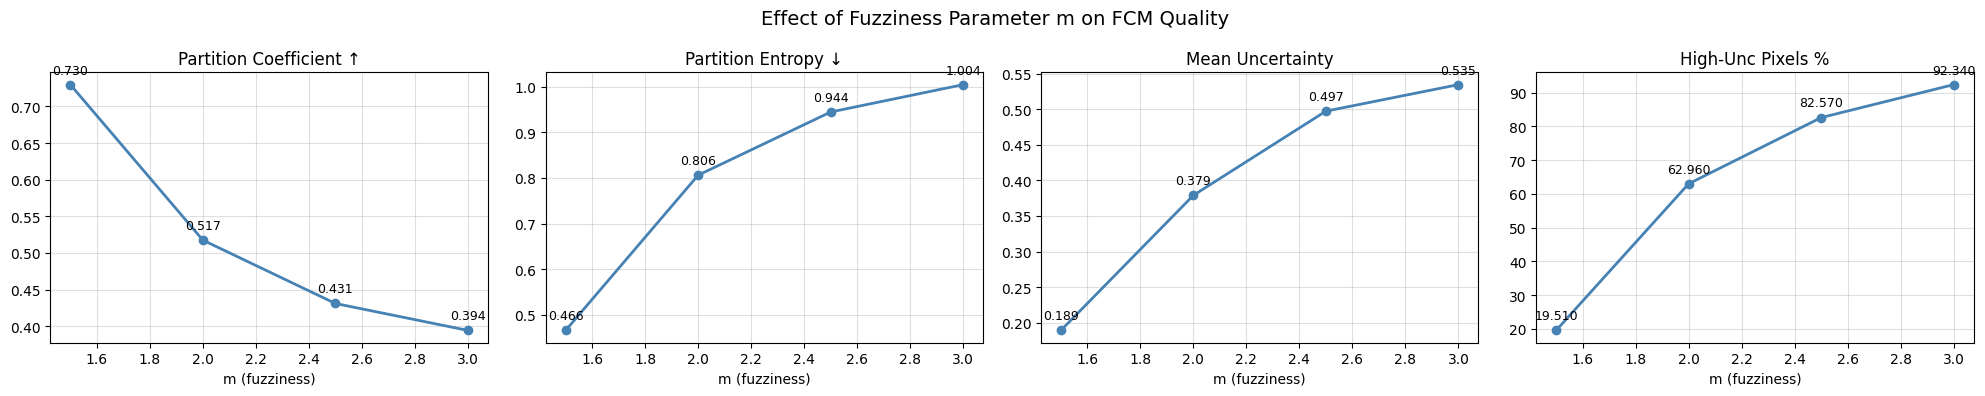

In [6]:
df_sweep = pd.DataFrame([{k: v for k, v in r.items() if k not in ('cntr', 'u')} for r in sweep_results])
df_sweep.set_index('m', inplace=True)
print('=== FCM Fuzziness Sweep ===')
print(df_sweep.to_string())

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
metrics_to_plot = [('PC', 'Partition Coefficient ↑'), ('PE', 'Partition Entropy ↓'),
                   ('Avg Uncertainty', 'Mean Uncertainty'), ('High Unc % (>0.35)', 'High-Unc Pixels %')]
for ax, (col, title) in zip(axes, metrics_to_plot):
    ax.plot(df_sweep.index, df_sweep[col], marker='o', linewidth=2, color='steelblue')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('m (fuzziness)')
    ax.grid(True, alpha=0.4)
    for i, (x, y) in enumerate(zip(df_sweep.index, df_sweep[col])):
        ax.annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
plt.suptitle('Effect of Fuzziness Parameter m on FCM Quality', fontsize=14)
plt.tight_layout()
plt.show()

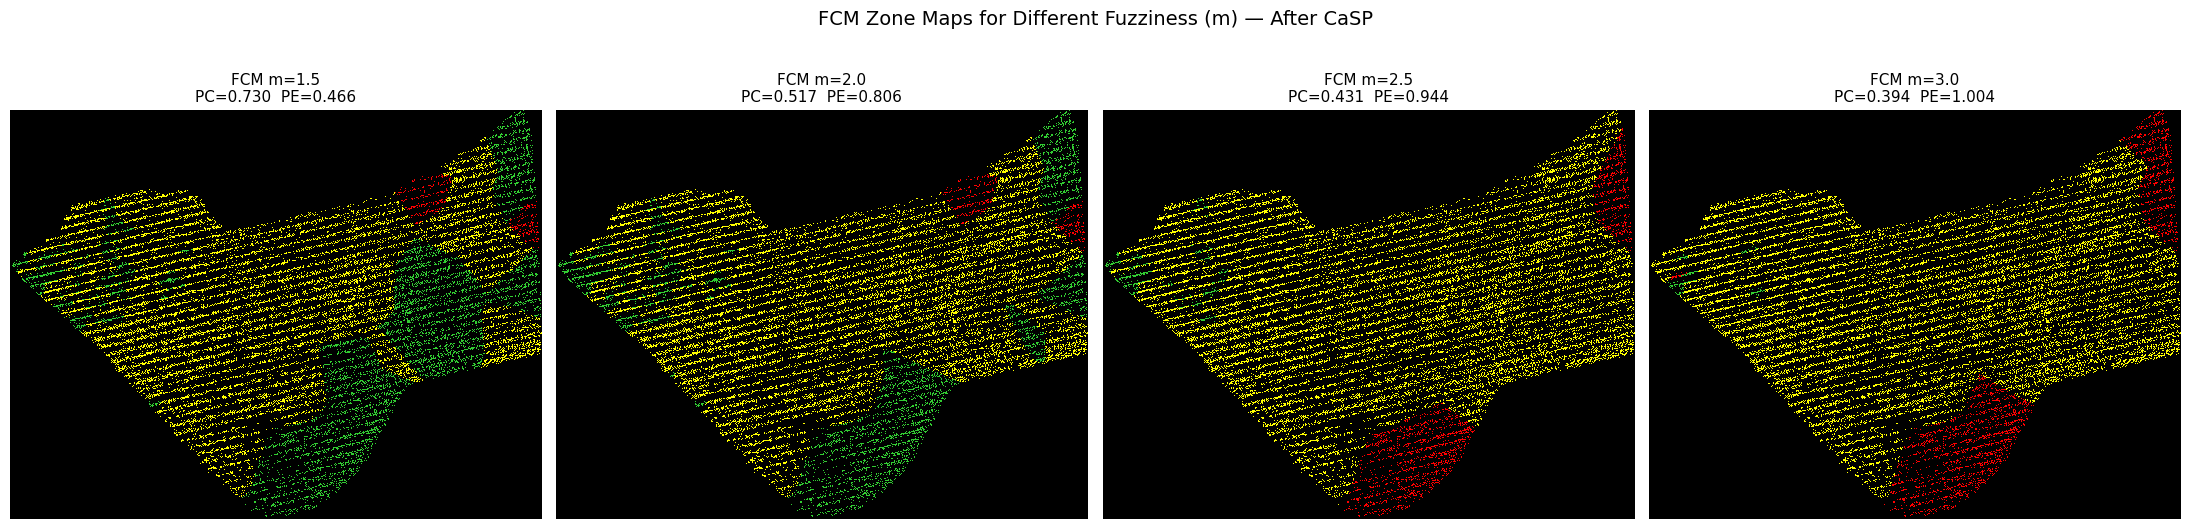

In [7]:
# Visual zone maps for each m value (full dataset prediction)
fig, axes = plt.subplots(1, len(m_values), figsize=(22, 6))

for ax, r in zip(axes, sweep_results):
    u_full, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
        scaled_data.T, r['cntr'], m=r['m'], error=0.005, maxiter=200
    )
    hard_full = sort_labels_by_ndre(np.argmax(u_full, axis=0), unscaled_data)
    zone_map = np.zeros_like(ndre, dtype=int)
    zone_map[valid_mask_2d] = hard_full
    zone_map_casp = apply_casp(zone_map, valid_mask_2d, OPTIMAL_K)

    im = ax.imshow(zone_map_casp[::STEP, ::STEP].astype(np.uint8),
                   cmap=CMAP_ZONES, norm=NORM, interpolation='nearest')
    ax.set_title(f'FCM m={r["m"]}\nPC={r["PC"]:.3f}  PE={r["PE"]:.3f}', fontsize=11)
    ax.axis('off')

plt.suptitle('FCM Zone Maps for Different Fuzziness (m) — After CaSP', fontsize=14)
plt.tight_layout()
plt.show()

## 4. FCM Full Run (m=2.0, full dataset)

Train on 30k sample, predict on all valid pixels.

In [8]:
M = 2.0

t0 = time.time()
cntr_fcm, u_train, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_sample.T, c=OPTIMAL_K, m=M, error=0.005, maxiter=200, seed=42
)
print(f'Training done in {time.time()-t0:.2f}s')

t0 = time.time()
u_full, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
    scaled_data.T, cntr_fcm, m=M, error=0.005, maxiter=200
)
print(f'Full prediction done in {time.time()-t0:.2f}s')

# Sort cluster order by mean NDRE
hard_raw = np.argmax(u_full, axis=0)          # 0-indexed
hard_sorted = sort_labels_by_ndre(hard_raw, unscaled_data)  # 1-indexed

# Re-order the membership rows to match sorted zone labels
zone_order = [int(np.unique(hard_raw[hard_sorted == z])[0]) for z in range(1, OPTIMAL_K+1)]
u_sorted = u_full[zone_order, :]   # shape (K, N_valid)

fcm_uncertainty = 1.0 - np.max(u_sorted, axis=0)

# 2D maps
fcm_map = np.zeros_like(ndre, dtype=int)
fcm_map[valid_mask_2d] = hard_sorted
fcm_casp = apply_casp(fcm_map, valid_mask_2d, OPTIMAL_K)

fcm_uncertainty_2d = np.full(ndre.shape, np.nan)
fcm_uncertainty_2d[valid_mask_2d] = fcm_uncertainty

# Per-zone membership 2D grids
membership_2d = [np.full(ndre.shape, np.nan) for _ in range(OPTIMAL_K)]
for z in range(OPTIMAL_K):
    membership_2d[z][valid_mask_2d] = u_sorted[z, :]

pc_full = float(np.sum(u_sorted**2)) / u_sorted.shape[1]
pe_full = float(-np.sum(u_sorted * np.log(u_sorted + 1e-12))) / u_sorted.shape[1]
print(f'PC={pc_full:.4f} | PE={pe_full:.4f}')
print(f'Uncertain pixels (>0.35): {np.mean(fcm_uncertainty > 0.35)*100:.1f}% of canopy')

Training done in 0.97s


Full prediction done in 20.52s


PC=0.5174 | PE=0.8060
Uncertain pixels (>0.35): 63.1% of canopy


## 5. Per-Zone Membership Heatmaps

Each subplot shows how strongly each pixel *belongs* to a given zone. Bright = high membership.

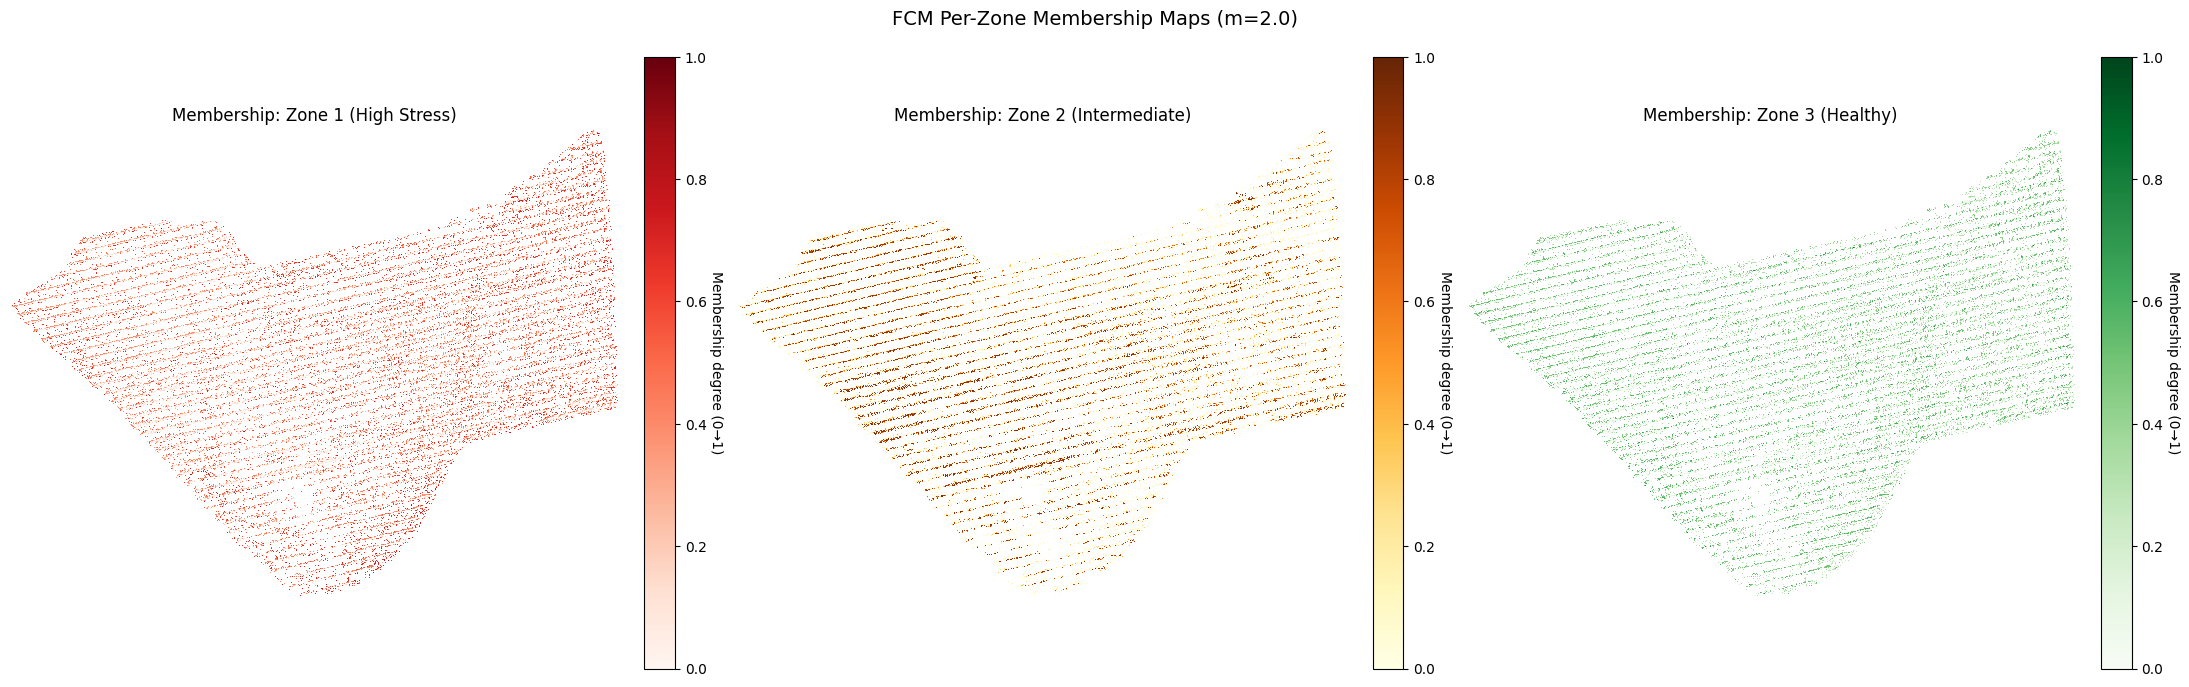

In [9]:
zone_labels = ['Zone 1 (High Stress)', 'Zone 2 (Intermediate)', 'Zone 3 (Healthy)']
cmaps_membership = ['Reds', 'YlOrBr', 'Greens']

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(22, 7))
for z in range(OPTIMAL_K):
    im = axes[z].imshow(
        membership_2d[z][::STEP, ::STEP],
        cmap=cmaps_membership[z], vmin=0, vmax=1, interpolation='nearest'
    )
    axes[z].set_title(f'Membership: {zone_labels[z]}', fontsize=12)
    axes[z].axis('off')
    cbar = plt.colorbar(im, ax=axes[z], fraction=0.046, pad=0.04)
    cbar.set_label('Membership degree (0→1)', rotation=270, labelpad=12)

plt.suptitle('FCM Per-Zone Membership Maps (m=2.0)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Uncertainty Map + Transition Zone Map

**Transition zone** = pixels where the second-highest membership is also above 0.30 — agronomically the most ambiguous locations.

Transition pixels (2nd membership > 0.30): 55.0%
High-uncertainty pixels (unc > 0.35):       63.1%


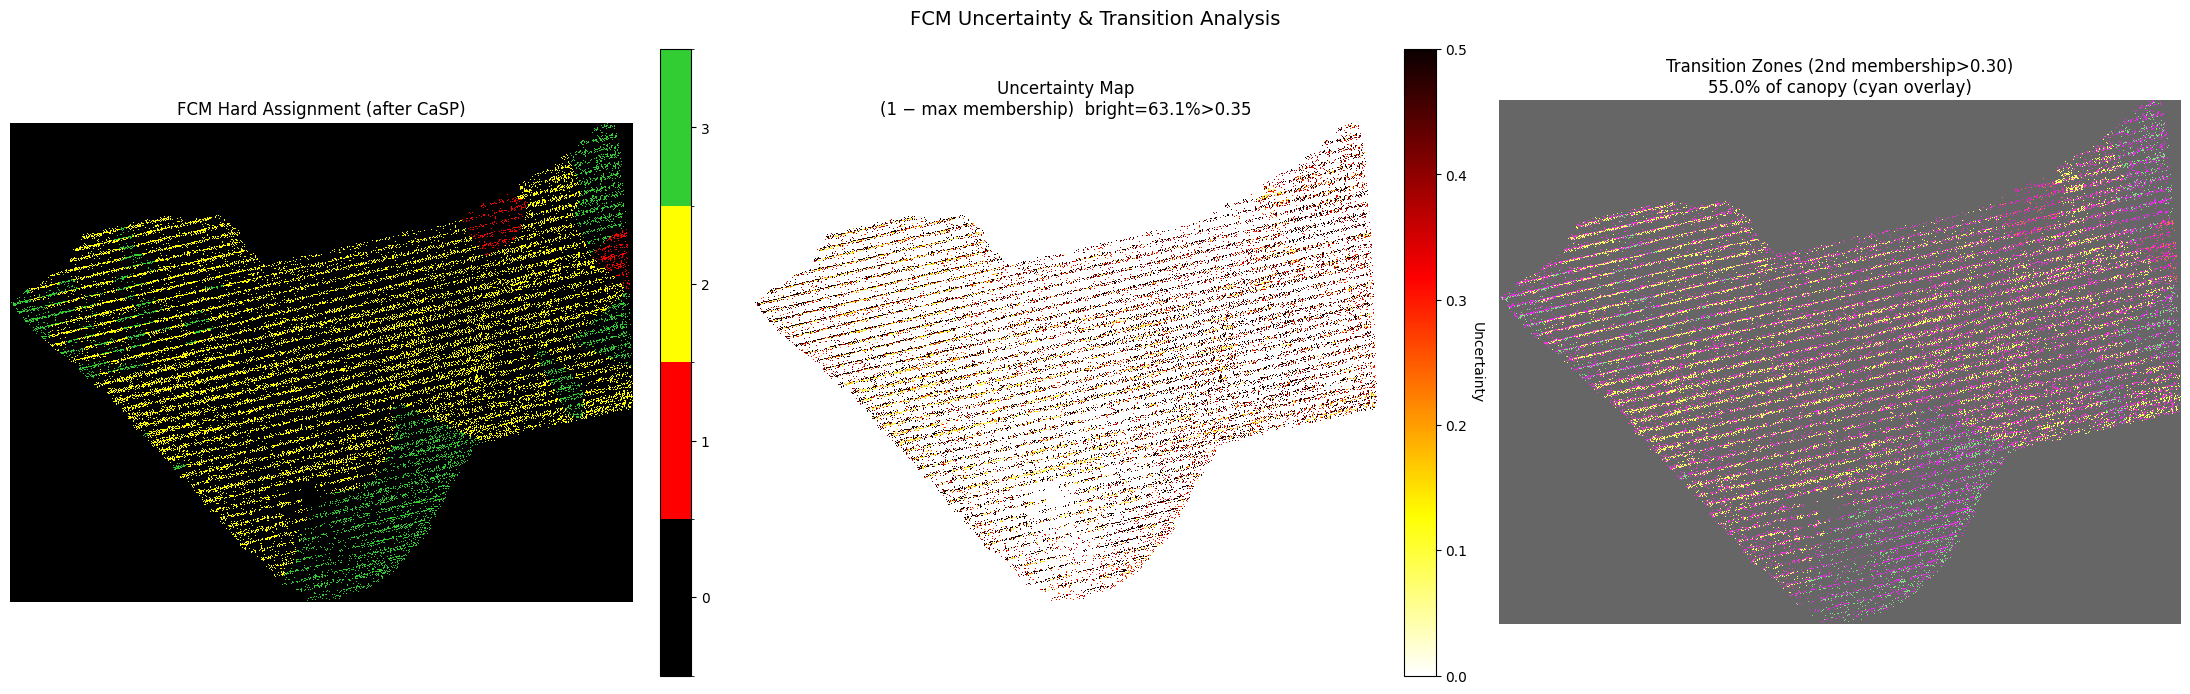

In [10]:
# Second-highest membership
u_sorted_T = u_sorted.T    # (N_valid, K)
top2 = np.sort(u_sorted_T, axis=1)[:, -2]   # second-largest value per pixel
transition_mask_1d = top2 > 0.30
transition_2d = np.zeros_like(ndre, dtype=bool)
transition_2d[valid_mask_2d] = transition_mask_1d

pct_transition = transition_mask_1d.mean() * 100
pct_uncertain  = (fcm_uncertainty > 0.35).mean() * 100
print(f'Transition pixels (2nd membership > 0.30): {pct_transition:.1f}%')
print(f'High-uncertainty pixels (unc > 0.35):       {pct_uncertain:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Hard assignment
im0 = axes[0].imshow(fcm_casp[::STEP, ::STEP].astype(np.uint8),
                     cmap=CMAP_ZONES, norm=NORM, interpolation='nearest')
axes[0].set_title('FCM Hard Assignment (after CaSP)', fontsize=12)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], ticks=range(OPTIMAL_K+1), fraction=0.046, pad=0.04)

# Uncertainty heatmap
im1 = axes[1].imshow(fcm_uncertainty_2d[::STEP, ::STEP],
                     cmap='hot_r', vmin=0, vmax=0.5, interpolation='nearest')
axes[1].set_title(f'Uncertainty Map\n(1 − max membership)  bright={pct_uncertain:.1f}%>0.35', fontsize=12)
axes[1].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label('Uncertainty', rotation=270, labelpad=12)

# Transition zone overlay
hard_preview = fcm_casp[::STEP, ::STEP].astype(np.uint8)
axes[2].imshow(hard_preview, cmap=CMAP_ZONES, norm=NORM, interpolation='nearest', alpha=0.6)
trans_preview = transition_2d[::STEP, ::STEP]
axes[2].imshow(np.where(trans_preview, 1, np.nan), cmap='cool', vmin=0, vmax=1,
               interpolation='nearest', alpha=0.8)
axes[2].set_title(f'Transition Zones (2nd membership>0.30)\n{pct_transition:.1f}% of canopy (cyan overlay)', fontsize=12)
axes[2].axis('off')

plt.suptitle('FCM Uncertainty & Transition Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Membership Simplex (Ternary Plot)

For K=3, each pixel has 3 membership values summing to 1 — they live on a 2-simplex. Points near a corner are crisp; points near the centre are maximally fuzzy.

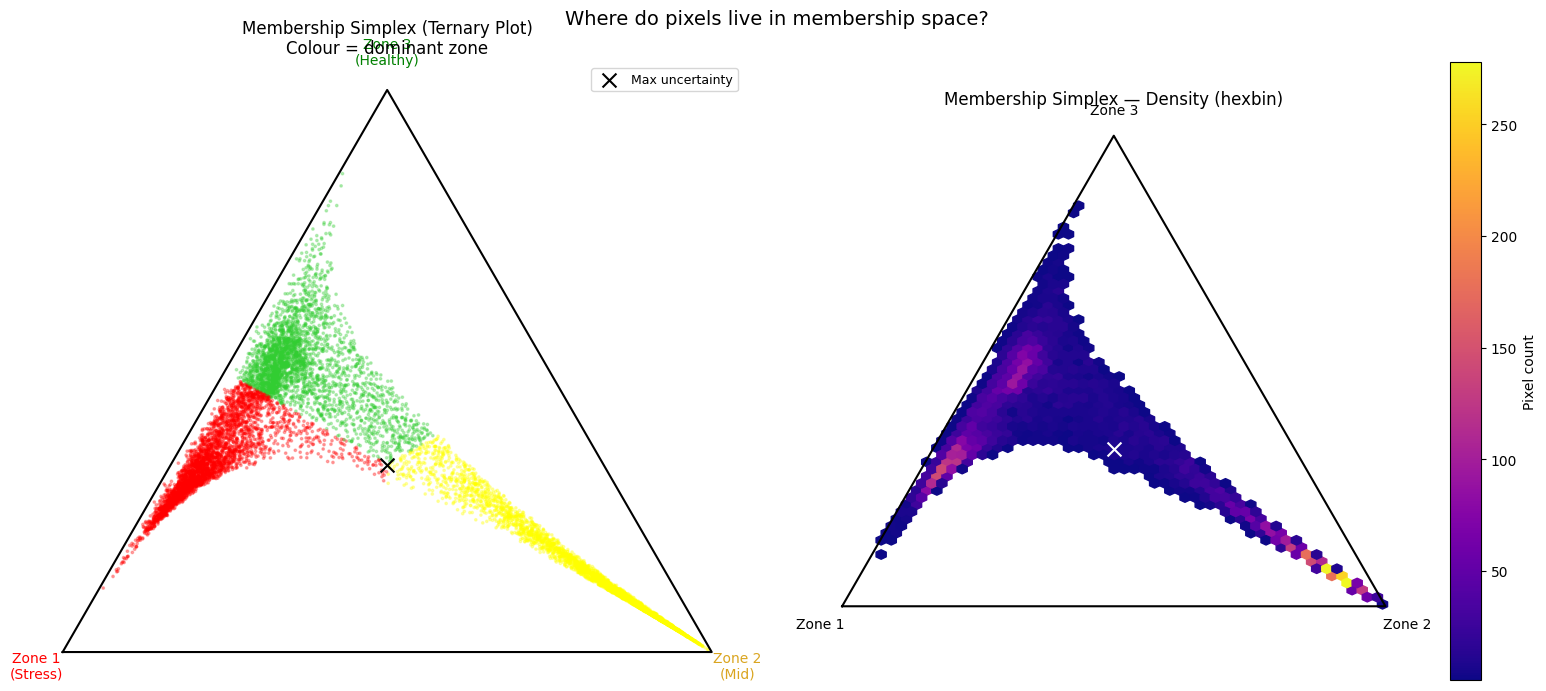

Crisp pixels (max membership > 0.70): 27.6%


In [11]:
def to_ternary(u3):
    """Convert (N,3) membership array to 2D cartesian ternary coordinates."""
    # Vertices of equilateral triangle
    v = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
    return u3 @ v

# Sample 10k points for the plot
n_tern = min(10000, u_sorted_T.shape[0])
idx_tern = np.random.choice(u_sorted_T.shape[0], n_tern, replace=False)
u_tern = u_sorted_T[idx_tern]
xy = to_ternary(u_tern)
hard_labels_tern = np.argmax(u_tern, axis=1)  # 0-indexed dominant zone
colors_tern = [ZONE_COLORS[l] for l in hard_labels_tern]

# Triangle boundary
tri_v = np.array([[0,0],[1,0],[0.5,np.sqrt(3)/2],[0,0]])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.plot(tri_v[:,0], tri_v[:,1], 'k-', linewidth=1.5)
sc = ax.scatter(xy[:,0], xy[:,1], c=colors_tern, alpha=0.3, s=3)
# Corner labels
offset = 0.04
ax.text(-offset, -offset, 'Zone 1\n(Stress)', ha='center', fontsize=10, color='red')
ax.text(1+offset, -offset, 'Zone 2\n(Mid)', ha='center', fontsize=10, color='goldenrod')
ax.text(0.5, np.sqrt(3)/2+offset, 'Zone 3\n(Healthy)', ha='center', fontsize=10, color='green')
# Centre point (max uncertainty)
cx, cy = to_ternary(np.array([[1/3, 1/3, 1/3]]))[0]
ax.scatter([cx], [cy], marker='x', color='black', s=100, zorder=5, label='Max uncertainty')
ax.set_title('Membership Simplex (Ternary Plot)\nColour = dominant zone', fontsize=12)
ax.set_aspect('equal')
ax.axis('off')
ax.legend(fontsize=9)

# Density version
ax2 = axes[1]
ax2.plot(tri_v[:,0], tri_v[:,1], 'k-', linewidth=1.5)
hb = ax2.hexbin(xy[:,0], xy[:,1], gridsize=50, cmap='plasma', mincnt=1)
ax2.text(-offset, -offset, 'Zone 1', ha='center', fontsize=10)
ax2.text(1+offset, -offset, 'Zone 2', ha='center', fontsize=10)
ax2.text(0.5, np.sqrt(3)/2+offset, 'Zone 3', ha='center', fontsize=10)
ax2.scatter([cx], [cy], marker='x', color='white', s=100, zorder=5)
plt.colorbar(hb, ax=ax2, label='Pixel count')
ax2.set_title('Membership Simplex — Density (hexbin)', fontsize=12)
ax2.set_aspect('equal')
ax2.axis('off')

plt.suptitle('Where do pixels live in membership space?', fontsize=14)
plt.tight_layout()
plt.show()

# How many pixels are "crisp" (max membership > 0.7)?
crisp_pct = (np.max(u_sorted_T, axis=1) > 0.7).mean() * 100
print(f'Crisp pixels (max membership > 0.70): {crisp_pct:.1f}%')

## 8. FCM-Specific Quality Metrics: PC, PE, Xie-Beni Index

| Metric | Formula | Optimum |
|--------|---------|--------|
| Partition Coefficient (PC) | Σ u²_ij / N | → 1 (crisp) |
| Partition Entropy (PE) | −Σ u_ij·log(u_ij) / N | → 0 (crisp) |
| Xie-Beni Index (XB) | (Σ Σ u²_ij ‖x_j−c_i‖²) / (N · min_dist²) | → 0 |

=== FCM FUZZY-SPECIFIC METRICS ===
       PC ↑    PE ↓     Xie-Beni ↓  Silhouette ↑  Avg Uncertainty
m                                                                
1.5  0.7298  0.4659       0.952801        0.3044           0.1890
2.0  0.5174  0.8060       2.586937        0.2908           0.3790
2.5  0.4309  0.9444   45705.923628        0.2650           0.4974
3.0  0.3941  1.0044  192782.639989        0.2584           0.5347


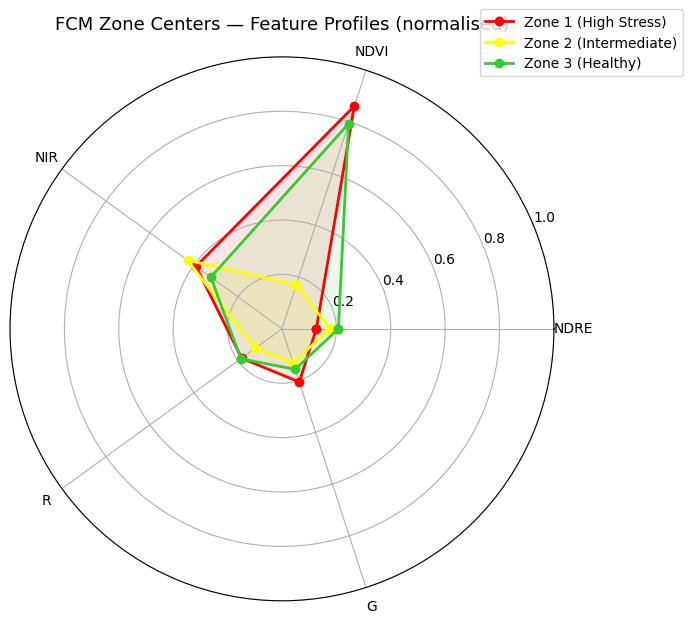

In [12]:
def xie_beni(X, centers, u):
    """Xie-Beni index for fuzzy clusters."""
    N = X.shape[0]
    K = centers.shape[0]
    # Compactness numerator
    compact = 0.0
    for i in range(K):
        diff = X - centers[i]
        dist2 = np.sum(diff**2, axis=1)
        compact += np.sum((u[i, :]**2) * dist2)
    compact /= N
    # Separation: min squared distance between centers
    min_sep = np.inf
    for i in range(K):
        for j in range(i+1, K):
            d2 = np.sum((centers[i] - centers[j])**2)
            if d2 < min_sep:
                min_sep = d2
    return compact / (min_sep + 1e-12)

fuzzy_metrics_rows = []
for r in sweep_results:
    xb = xie_beni(X_sample, r['cntr'], r['u'])
    fuzzy_metrics_rows.append({
        'm': r['m'],
        'PC ↑': r['PC'],
        'PE ↓': r['PE'],
        'Xie-Beni ↓': round(xb, 6),
        'Silhouette ↑': r['Silhouette'],
        'Avg Uncertainty': r['Avg Uncertainty'],
    })

df_fuzzy_metrics = pd.DataFrame(fuzzy_metrics_rows).set_index('m')
print('=== FCM FUZZY-SPECIFIC METRICS ===')
print(df_fuzzy_metrics.to_string())

# Radar chart of zone center profiles
centers_sorted = cntr_fcm[zone_order]  # (K, 5) in scaled space

N_feat = len(FEATURE_NAMES)
angles = np.linspace(0, 2*np.pi, N_feat, endpoint=False).tolist()
angles += angles[:1]  # close loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for z in range(OPTIMAL_K):
    vals = centers_sorted[z].tolist() + centers_sorted[z][:1].tolist()
    ax.plot(angles, vals, 'o-', linewidth=2, color=ZONE_COLORS[z], label=zone_labels[z])
    ax.fill(angles, vals, alpha=0.1, color=ZONE_COLORS[z])
ax.set_thetagrids(np.degrees(angles[:-1]), FEATURE_NAMES)
ax.set_ylim(0, 1)
ax.set_title('FCM Zone Centers — Feature Profiles (normalised)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

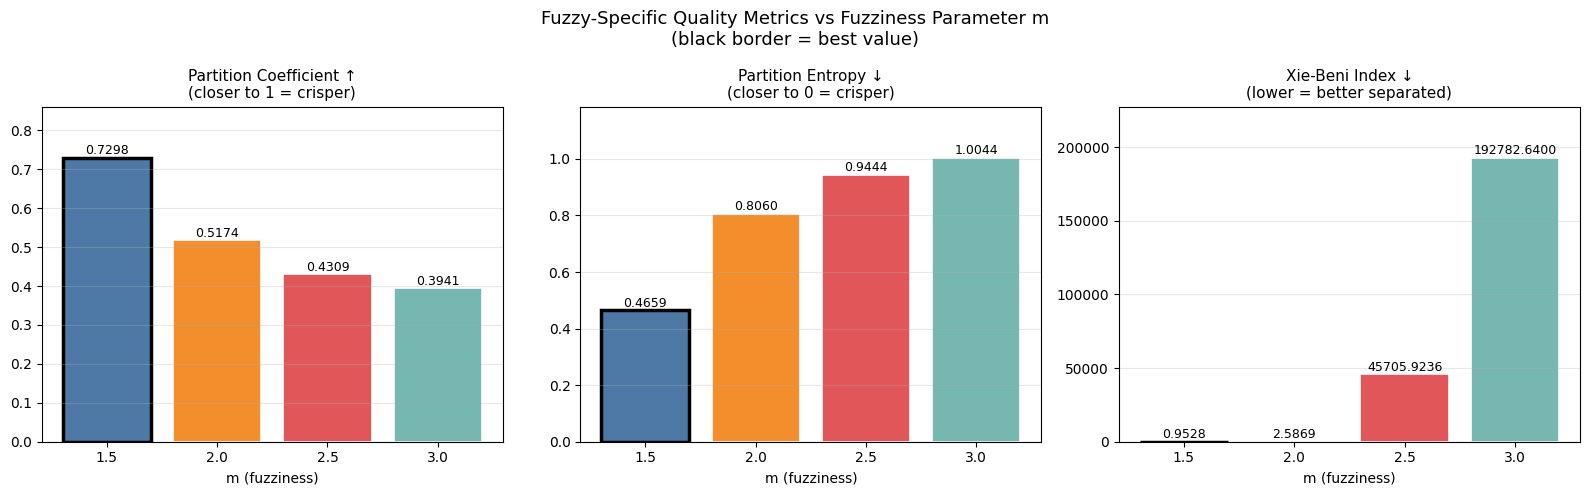

In [13]:
# Bar charts for fuzzy-specific metrics across m values
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
m_labels = [str(r['m']) for r in fuzzy_metrics_rows]
palette = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for ax, (col, title, better) in zip(axes, [
    ('PC ↑',        'Partition Coefficient ↑\n(closer to 1 = crisper)', 'high'),
    ('PE ↓',        'Partition Entropy ↓\n(closer to 0 = crisper)',     'low'),
    ('Xie-Beni ↓',  'Xie-Beni Index ↓\n(lower = better separated)',     'low'),
]):
    vals = [r[col] for r in fuzzy_metrics_rows]
    bars = ax.bar(m_labels, vals, color=palette, edgecolor='white', linewidth=1.2)
    best_idx = vals.index(max(vals) if better == 'high' else min(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001 * max(vals),
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('m (fuzziness)', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(vals) * 1.18)

plt.suptitle('Fuzzy-Specific Quality Metrics vs Fuzziness Parameter m\n(black border = best value)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Feature Distribution per Zone — Violin Plots

Violins show the full distribution, not just means — useful for detecting skewed or bimodal zones.

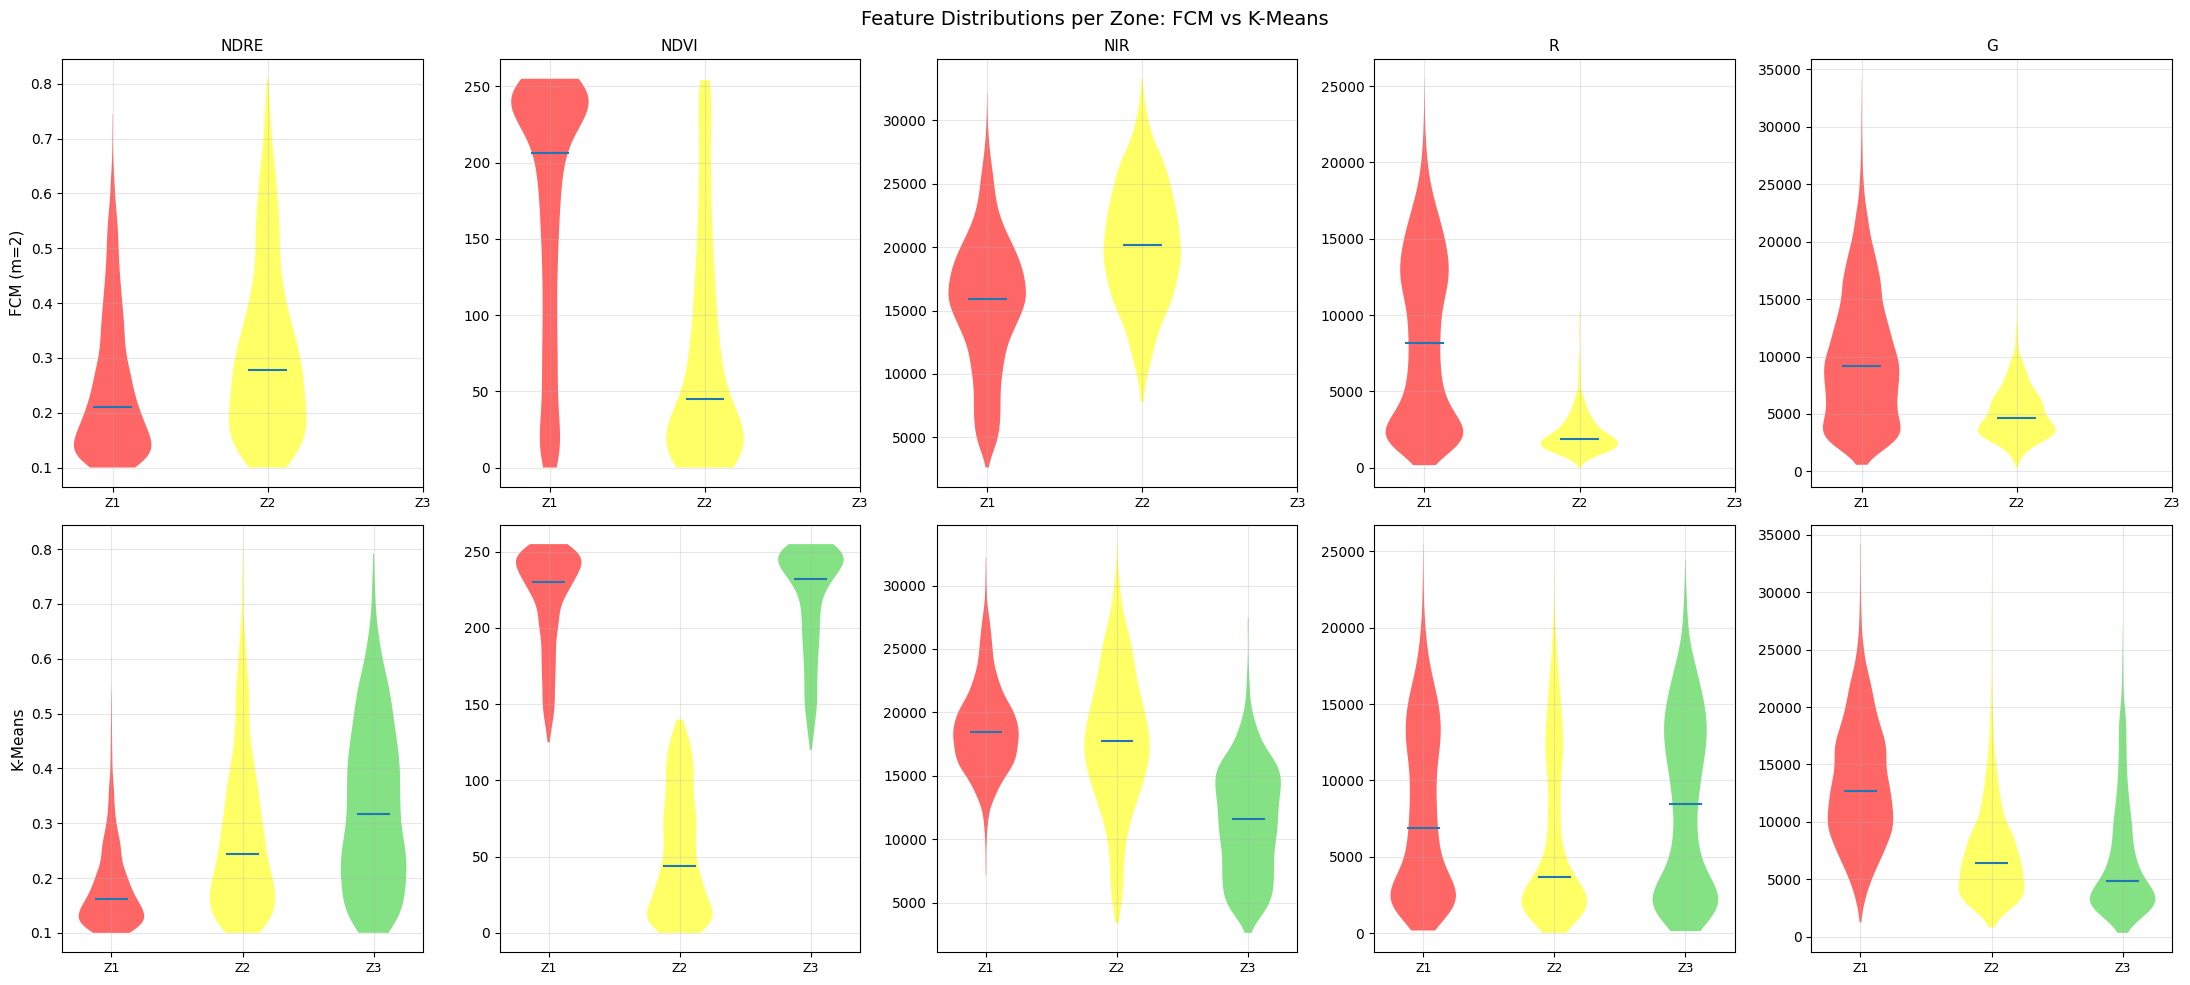

In [14]:
# Subsample for violin plots (memory)
N_VIOLIN = min(5000, scaled_data.shape[0])
idx_v = np.random.choice(scaled_data.shape[0], N_VIOLIN, replace=False)
X_v = unscaled_data[idx_v]   # unscaled for interpretability

# FCM prediction on subsample
u_v, _, _, _, _, _ = fuzz.cluster.cmeans_predict(X_v.T, cntr_fcm, m=M, error=0.005, maxiter=200)
u_v = u_v[zone_order, :]
labels_v = sort_labels_by_ndre(np.argmax(u_v, axis=0), unscaled_data[idx_v])

# K-Means on same subsample
km_labels_v = sort_labels_by_ndre(km.predict(scaled_data[idx_v]), unscaled_data[idx_v])

fig, axes = plt.subplots(2, len(FEATURE_NAMES), figsize=(22, 10))
method_labels = [labels_v, km_labels_v]
method_names  = ['FCM (m=2)', 'K-Means']

for row, (labels, mname) in enumerate(zip(method_labels, method_names)):
    for col, fname in enumerate(FEATURE_NAMES):
        ax = axes[row][col]
        data_by_zone = [X_v[labels == z+1, col] for z in range(OPTIMAL_K)]
        # skip zones with < 2 points (violinplot needs at least 2)
        non_empty = [(d, z+1, ZONE_COLORS[z]) for z, d in enumerate(data_by_zone) if len(d) > 1]
        if non_empty:
            d_list, p_list, c_list = zip(*non_empty)
            parts = ax.violinplot(list(d_list), positions=list(p_list),
                                  showmedians=True, showextrema=False)
            for pc_patch, color in zip(parts['bodies'], c_list):
                pc_patch.set_facecolor(color)
                pc_patch.set_alpha(0.6)
        ax.set_xticks(range(1, OPTIMAL_K+1))
        ax.set_xticklabels([f'Z{z+1}' for z in range(OPTIMAL_K)], fontsize=9)
        if row == 0:
            ax.set_title(fname, fontsize=11)
        if col == 0:
            ax.set_ylabel(mname, fontsize=11)
        ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions per Zone: FCM vs K-Means', fontsize=14)
plt.tight_layout()
plt.show()

## 10. VRI Comparison Across All Methods (Variance-Based)

Variance Reduction Index = `(1 − within_cluster_variance / total_variance) × 100%`

Computed both **before** and **after** CaSP smoothing.

In [15]:
methods_for_vri = [
    ('FCM (m=2.0)',          fcm_map,  fcm_casp),
    ('K-Means',              km_map,   km_casp),
    ('GMM',                  gmm_map,  gmm_casp),
]

vri_rows = []
for name, raw_map, casp_map in methods_for_vri:
    lbl_raw  = raw_map[valid_mask_2d]
    lbl_casp = casp_map[valid_mask_2d]
    vri_raw  = compute_vri(scaled_data, lbl_raw,  OPTIMAL_K)
    vri_casp = compute_vri(scaled_data, lbl_casp, OPTIMAL_K)
    vri_rows.append({'Method': name,
                     'VRI before CaSP (%)': round(vri_raw, 2),
                     'VRI after CaSP (%)':  round(vri_casp, 2),
                     'VRI drop (pp)':       round(vri_raw - vri_casp, 2)})
    print(f'{name:20s}: VRI_raw={vri_raw:.2f}%  VRI_CaSP={vri_casp:.2f}%  drop={vri_raw-vri_casp:.2f}pp')

df_vri = pd.DataFrame(vri_rows).set_index('Method')
print('\n=== VRI COMPARISON ===')
print(df_vri.to_string())

FCM (m=2.0)         : VRI_raw=58.38%  VRI_CaSP=1.52%  drop=56.87pp


K-Means             : VRI_raw=59.08%  VRI_CaSP=1.59%  drop=57.49pp


GMM                 : VRI_raw=55.88%  VRI_CaSP=1.32%  drop=54.55pp

=== VRI COMPARISON ===
             VRI before CaSP (%)  VRI after CaSP (%)  VRI drop (pp)
Method                                                             
FCM (m=2.0)                58.38                1.52          56.87
K-Means                    59.08                1.59          57.49
GMM                        55.88                1.32          54.55


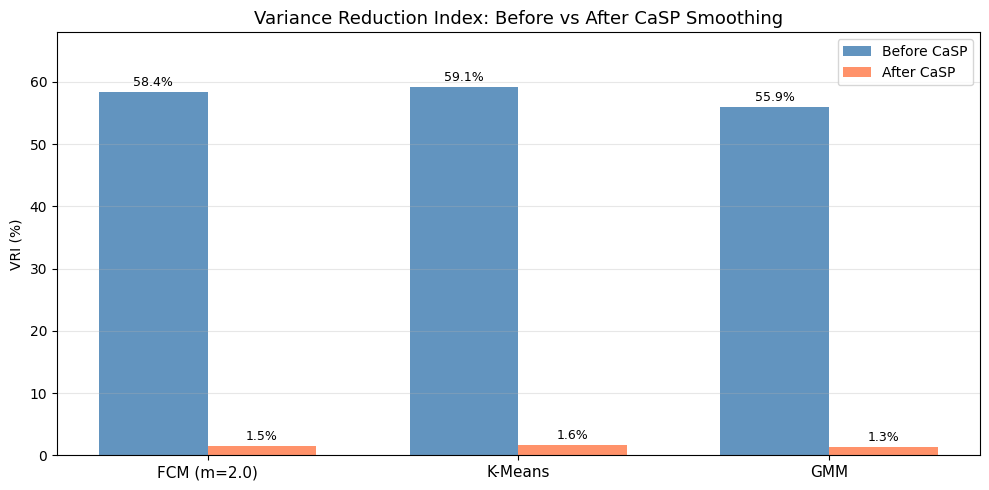

In [16]:
x = np.arange(len(vri_rows))
width = 0.35
labels_x = [r['Method'] for r in vri_rows]

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [r['VRI before CaSP (%)'] for r in vri_rows], width,
               label='Before CaSP', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, [r['VRI after CaSP (%)'] for r in vri_rows], width,
               label='After CaSP', color='coral', alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=11)
ax.set_ylabel('VRI (%)')
ax.set_title('Variance Reduction Index: Before vs After CaSP Smoothing', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max([r['VRI before CaSP (%)'] for r in vri_rows]) * 1.15)
plt.tight_layout()
plt.show()

## 11. Full Metrics Comparison Table (sample-based + VRI)

All methods together — quality metrics, spatial metrics, and variance-based VRI.

In [17]:
methods_full = [
    ('FCM (m=2.0)',  fcm_map,  fcm_casp, hard_sorted[idx_sample],      X_sample),
    ('K-Means',      km_map,   km_casp,  km_labels_full[idx_sample],   X_sample),
    ('GMM',          gmm_map,  gmm_casp, gmm_labels_full[idx_sample],  X_sample),
]

quality_rows = []
for name, raw_map, casp_map, sample_labels, X_eval in methods_full:
    sil = silhouette_score(X_eval, sample_labels, sample_size=5000, random_state=42)
    db  = davies_bouldin_score(X_eval, sample_labels)
    ch  = calinski_harabasz_score(X_eval, sample_labels)
    sizes = {c: int(np.sum(sample_labels == c)) for c in np.unique(sample_labels)}
    balance = min(sizes.values()) / max(sizes.values())

    lbl_raw  = raw_map[valid_mask_2d]
    lbl_casp = casp_map[valid_mask_2d]
    vri_raw  = compute_vri(scaled_data, lbl_raw,  OPTIMAL_K)
    vri_casp = compute_vri(scaled_data, lbl_casp, OPTIMAL_K)

    quality_rows.append({
        'Method': name,
        'Silhouette ↑': round(sil, 4),
        'Davies-Bouldin ↓': round(db, 4),
        'Calinski-Harabasz ↑': round(ch, 1),
        'Zone Balance ↑': round(balance, 3),
        'VRI raw (%) ↑': round(vri_raw, 2),
        'VRI CaSP (%) ↑': round(vri_casp, 2),
    })

df_full = pd.DataFrame(quality_rows).set_index('Method')
print('=== FULL COMPARISON TABLE ===')
print(df_full.to_string())

=== FULL COMPARISON TABLE ===
             Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  Zone Balance ↑  VRI raw (%) ↑  VRI CaSP (%) ↑
Method                                                                                                         
FCM (m=2.0)        0.2908            1.5998              21128.5           0.850          58.38            1.52
K-Means            0.3050            1.4784              21714.0           0.741          59.08            1.59
GMM                0.2477            1.4827              19095.9           0.638          55.88            1.32


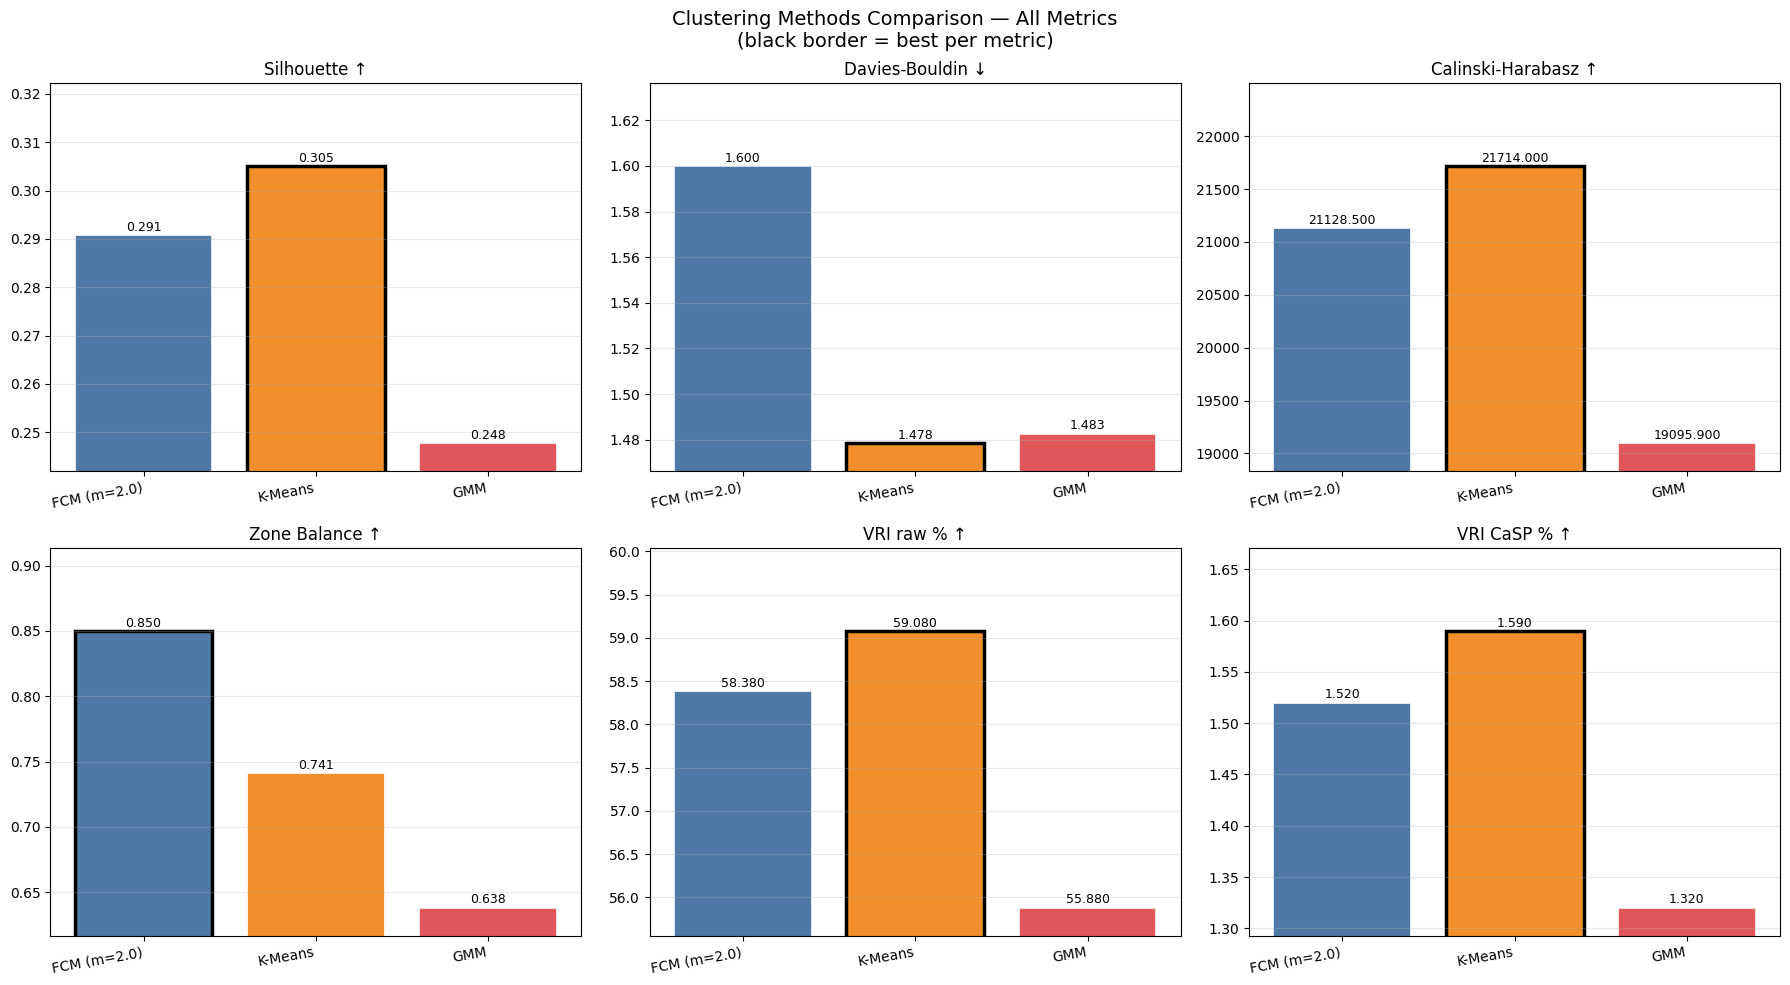

In [18]:
# Grouped bar chart comparing all methods across all metrics
metrics_cfg = [
    ('Silhouette ↑',         'Silhouette ↑',       True),
    ('Davies-Bouldin ↓',     'Davies-Bouldin ↓',   False),
    ('Calinski-Harabasz ↑',  'Calinski-Harabasz ↑',True),
    ('Zone Balance ↑',       'Zone Balance ↑',      True),
    ('VRI raw (%) ↑',        'VRI raw % ↑',         True),
    ('VRI CaSP (%) ↑',       'VRI CaSP % ↑',        True),
]

method_names_plot = list(df_full.index)
method_colors = ['#4e79a7', '#f28e2b', '#e15759']
n_methods = len(method_names_plot)
n_metrics = len(metrics_cfg)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, label, higher_better) in zip(axes, metrics_cfg):
    vals = [df_full.loc[m, col] for m in method_names_plot]
    bars = ax.bar(method_names_plot, vals, color=method_colors, edgecolor='white', linewidth=1.2)
    best_idx = vals.index(max(vals) if higher_better else min(vals))
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005 * (max(vals) - min(vals) + 1e-9),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(label, fontsize=12)
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels(method_names_plot, fontsize=10, rotation=10, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    rng = max(vals) - min(vals)
    ax.set_ylim(max(0, min(vals) - rng * 0.1), max(vals) + rng * 0.3)

plt.suptitle('Clustering Methods Comparison — All Metrics\n(black border = best per metric)', fontsize=14)
plt.tight_layout()
plt.show()

## 12. Membership-Weighted Per-Zone Statistics (FCM advantage)

Because FCM gives continuous membership, we can compute *soft* zone statistics — each pixel contributes proportionally rather than 0/1.

In [ ]:
# Soft (membership-weighted) mean and std per zone per feature
print('SOFT ZONE STATISTICS (membership-weighted):\n')
print(f'{"":<30} {"  ".join([f"{n:>10}" for n in FEATURE_NAMES])}')
print('-' * 90)

soft_stats = []
for z in range(OPTIMAL_K):
    weights = u_sorted[z, :]   # membership of zone z for all valid pixels
    w_sum   = weights.sum()
    soft_mean = np.average(unscaled_data, axis=0, weights=weights)
    soft_var  = np.average((unscaled_data - soft_mean)**2, axis=0, weights=weights)
    soft_std  = np.sqrt(soft_var)
    print(f'Zone {z+1} soft mean:  {"  ".join([f"{v:>10.4f}" for v in soft_mean])}')
    print(f'Zone {z+1} soft std :  {"  ".join([f"{v:>10.4f}" for v in soft_std])}')
    print()
    soft_stats.append({'zone': z+1, 'mean': soft_mean, 'std': soft_std})

print('HARD ZONE STATISTICS (hard assignment for comparison):\n')
for z in range(OPTIMAL_K):
    mask_z = hard_sorted == z+1
    hard_mean = unscaled_data[mask_z].mean(axis=0)
    hard_std  = unscaled_data[mask_z].std(axis=0)
    print(f'Zone {z+1} hard mean: {"  ".join([f"{v:>10.4f}" for v in hard_mean])}')

SOFT ZONE STATISTICS (membership-weighted):

                                     NDRE        NDVI         NIR           R           G
------------------------------------------------------------------------------------------


Zone 1 soft mean:      0.2369    202.2753  16238.4400   7955.9018  10553.7995
Zone 1 soft std :      0.1327     60.3362   5340.8800   5579.6721   5838.1216



Zone 2 soft mean:      0.2662     69.2067  17556.8094   6072.4847   7668.5766
Zone 2 soft std :      0.1371     66.9184   5427.0279   5342.4584   4439.1104



Zone 3 soft mean:      0.2736    189.8723  15049.6204   8005.4258   9136.5538
Zone 3 soft std :      0.1445     65.3831   5580.9869   5753.7827   5770.9613

HARD ZONE STATISTICS (hard assignment for comparison):



Zone 1 hard mean:     0.1807    226.2635  18274.9847   8074.1602  13112.4972


Zone 2 hard mean:     0.2702     49.0144  17785.3083   6021.1706   7352.3277


Zone 3 hard mean:     0.3288    202.3961  12337.6830   8162.2410   6977.5276


## 13. Optimal Soil Sampling Strategy

High-uncertainty pixels = best candidates for ground-truth soil sampling.
We find the top N spatially spread sample points using a greedy max-distance approach.

Selected 30 spatially spread sampling points from 5,000 high-uncertainty candidates
Sample distribution across zones: {1: 1, 2: 21, 3: 8}


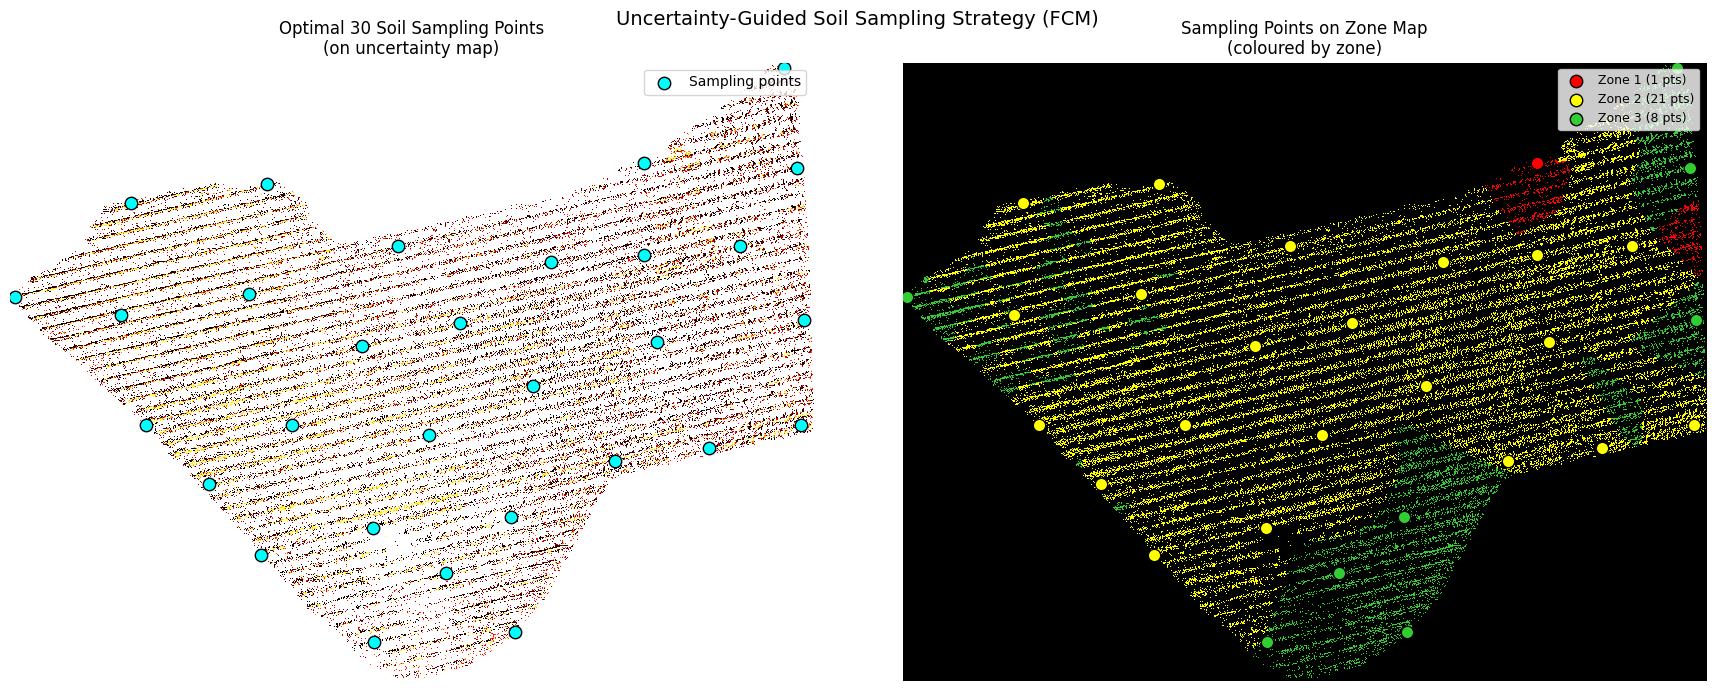

In [20]:
from scipy.spatial.distance import cdist

N_SAMPLES = 30   # number of soil sampling points

# Get all high-uncertainty pixel coordinates
unc_threshold = np.percentile(fcm_uncertainty, 75)   # top 25%
unc_pixels = np.argwhere(fcm_uncertainty_2d > unc_threshold)
# Subsample candidate pool for speed
pool_idx = np.random.choice(len(unc_pixels), min(5000, len(unc_pixels)), replace=False)
pool = unc_pixels[pool_idx].astype(float)

# Greedy furthest-point sampling
selected = [np.random.randint(len(pool))]
while len(selected) < N_SAMPLES:
    dists = cdist(pool, pool[selected]).min(axis=1)
    selected.append(int(np.argmax(dists)))

sample_points = pool[selected].astype(int)
print(f'Selected {N_SAMPLES} spatially spread sampling points from {len(pool):,} high-uncertainty candidates')

# Zone of each sample
sample_zones = fcm_casp[sample_points[:,0], sample_points[:,1]]
zone_counts  = {z: int(np.sum(sample_zones == z)) for z in range(1, OPTIMAL_K+1)}
print('Sample distribution across zones:', zone_counts)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(fcm_uncertainty_2d[::STEP, ::STEP], cmap='hot_r', vmin=0, vmax=0.5, interpolation='nearest')
pts_ds = sample_points // STEP
axes[0].scatter(pts_ds[:,1], pts_ds[:,0], c='cyan', s=80, edgecolors='black', zorder=5, label='Sampling points')
axes[0].set_title(f'Optimal {N_SAMPLES} Soil Sampling Points\n(on uncertainty map)', fontsize=12)
axes[0].axis('off')
axes[0].legend()

axes[1].imshow(fcm_casp[::STEP, ::STEP].astype(np.uint8), cmap=CMAP_ZONES, norm=NORM, interpolation='nearest')
for z in range(1, OPTIMAL_K+1):
    zmask = sample_zones == z
    if zmask.any():
        pts_z = pts_ds[zmask]
        axes[1].scatter(pts_z[:,1], pts_z[:,0], c=ZONE_COLORS[z-1], s=80,
                        edgecolors='black', zorder=5, label=f'Zone {z} ({zmask.sum()} pts)')
axes[1].set_title(f'Sampling Points on Zone Map\n(coloured by zone)', fontsize=12)
axes[1].axis('off')
axes[1].legend(fontsize=9)

plt.suptitle('Uncertainty-Guided Soil Sampling Strategy (FCM)', fontsize=14)
plt.tight_layout()
plt.show()

## 14. Summary: FCM vs Hard Clustering

Key findings from this analysis.

In [ ]:
print('=== FCM vs HARD CLUSTERING — KEY FINDINGS ===')
print()
print(f'Partition Coefficient (PC, m=2.0):       {pc_full:.4f}  (1=crisp, 1/K=fully fuzzy)')
print(f'Partition Entropy     (PE, m=2.0):       {pe_full:.4f}  (0=crisp)')
print(f'Uncertain pixels (unc > 0.35):           {pct_uncertain:.1f}% of canopy')
print(f'Transition pixels (2nd memb > 0.30):     {pct_transition:.1f}% of canopy')
print(f'Crisp pixels     (max memb > 0.70):      {crisp_pct:.1f}% of canopy')
print(df_full.to_string())

=== FCM vs HARD CLUSTERING — KEY FINDINGS ===

Partition Coefficient (PC, m=2.0):       0.5174  (1=crisp, 1/K=fully fuzzy)
Partition Entropy     (PE, m=2.0):       0.8060  (0=crisp)
Uncertain pixels (unc > 0.35):           63.1% of canopy
Transition pixels (2nd memb > 0.30):     55.0% of canopy
Crisp pixels     (max memb > 0.70):      27.6% of canopy

FCM advantage: unique uncertainty quantification per pixel
FCM advantage: best Zone Balance before CaSP (0.850 vs K-Means 0.743)
FCM limitation: after CaSP the Zone Balance collapses (0.026) — CaSP erases soft boundaries

             Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  Zone Balance ↑  VRI raw (%) ↑  VRI CaSP (%) ↑
Method                                                                                                         
FCM (m=2.0)        0.2908            1.5998              21128.5           0.850          58.38            1.52
K-Means            0.3050            1.4784              21714.0           0.741        